# 04 — Encoder Selection Experiment

**Goal:** Select the best text representation and embedding model for Bulgarian news event clustering.


In [ ]:
import re
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import torch
import umap
import hdbscan

from sentence_transformers import SentenceTransformer
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

# 1. Load data 

In [2]:
df = pd.read_parquet("../data/processed/articles_clean.parquet")

end_date = pd.Timestamp("2026-05-21", tz="UTC")
start_date = end_date - pd.Timedelta(days=3)

exp_df = (
    df[(df["published_at_dt"] >= start_date) & (df["published_at_dt"] <= end_date)]
    .copy()
    .reset_index(drop=True)
)

print(f"Total articles : {len(exp_df)}")
print(
    f"Date range     : {exp_df['published_at_dt'].min().date()} → {exp_df['published_at_dt'].max().date()}"
)
print("\nPer source:")
print(exp_df["source"].value_counts().to_string())

Total articles : 3648
Date range     : 2026-05-18 → 2026-05-21

Per source:
source
24chasa         909
actualno        553
fakti           424
bta             338
standartnews    322
monitor         301
vesti           286
nova            252
segabg          115
banker          101
economic         47


In [7]:
exp_df.groupby([exp_df["published_at_dt"].dt.date, "source"]).size().unstack(fill_value=0)

source,24chasa,actualno,banker,bta,economic,fakti,monitor,nova,segabg,standartnews,vesti
published_at_dt,,,,,,,,,,,
2026-05-18,274,170,33,103,15,148,113,87,34,107,92
2026-05-19,322,190,38,117,16,148,92,84,39,119,93
2026-05-20,312,193,30,118,16,128,96,81,42,96,101
2026-05-21,1,0,0,0,0,0,0,0,0,0,0


In [4]:
def extract_lead(text: str, n_sentences: int = 3) -> str:
    if not isinstance(text, str):
        return ""
    sentences = re.split(r"(?<=[.!?])\s+", text.strip())
    return " ".join(sentences[:n_sentences])


exp_df["lead"] = exp_df["full_text"].apply(extract_lead)

TEXT_VARIANTS = {
    "full_text": exp_df["full_text"].fillna("").tolist(),
    "title": exp_df["title"].tolist(),
    "lead": exp_df["lead"].tolist(),
    "title+lead": (exp_df["title"] + ". " + exp_df["lead"]).tolist(),
}

print("Text variants prepared:")
for k, v in TEXT_VARIANTS.items():
    sample_len = sum(len(t.split()) for t in v) / len(v)
    print(f"  {k:<15}: avg {sample_len:.0f} words")

Text variants prepared:
  full_text      : avg 335 words
  title          : avg 11 words
  lead           : avg 66 words
  title+lead     : avg 77 words


In [15]:
DEVICE = (
    "mps"
    if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available() else "cpu"
)
print(f"Device: {DEVICE}")

TEXT_MODEL_ID = "BAAI/bge-m3"
text_model = SentenceTransformer(TEXT_MODEL_ID, device=DEVICE)
print("Model loaded.")

Device: mps


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Model loaded.


In [18]:
def similarity_stats(emb, name, df):
    sim = cosine_similarity(emb)

    sources = df["source"].to_numpy()
    same_mask = sources[:, None] == sources[None, :]
    upper = np.triu(np.ones(len(sim), dtype=bool), k=1)

    same = sim[upper & same_mask]
    cross = sim[upper & ~same_mask]

    return {
        "variant": name,
        "same_source_mean": round(float(np.mean(same)), 3),
        "cross_source_mean": round(float(np.mean(cross)), 3),
        "gap": round(float(np.mean(same) - np.mean(cross)), 3),
        "cross_source_std": round(float(np.std(cross)), 3),
    }

# 2. Model comparison

- https://huggingface.co/AIaLT-IICT/modern_bert_bg_base_uncased
- https://huggingface.co/AIaLT-IICT/bert_bg_lit_web_extra_large_uncased


In [5]:
BEST_TEXT_VARIANT = "title+lead"
texts = (exp_df["title"] + ". " + exp_df["lead"]).tolist()

print(f"Using text variant: {BEST_TEXT_VARIANT}")
print(f"Sample: {texts[0][:150]}")

Using text variant: title+lead
Sample: В телефонен разговор със Зеленски Стармър потвърди подкрепата на Великобритания за Украйна. В телефонен разговор със Зеленски Стармър потвърди подкреп


In [13]:
def encode_model(model_id: str, texts: list, device: str = DEVICE) -> np.ndarray:
    m = SentenceTransformer(model_id, device=device)
    kwargs = dict(
        normalize_embeddings=True,
        show_progress_bar=True,
        batch_size=32,
    )
    if "qwen" in model_id.lower():
        kwargs["prompt_name"] = "query"
    return m.encode(texts, **kwargs)

In [12]:
MODELS = {
    "ModernBERT-BG-large": "AIaLT-IICT/modern_bert_bg_large_uncased",
    "BERT-BG-xlarge": "AIaLT-IICT/bert_bg_lit_web_extra_large_uncased",
    "BGE-M3": "BAAI/bge-m3",
    "Qwen3-0.6B": "Qwen/Qwen3-Embedding-0.6B",
    "LaBSE": "sentence-transformers/LaBSE",
}

In [14]:
model_embeddings = {}
for name, model_id in MODELS.items():
    print(f"\n{'='*40}\nEncoding: {name}")
    emb = encode_model(model_id, texts)
    model_embeddings[name] = emb
    np.save(f"../data/experiments/embeddings/{name.replace('/', '_')}.npy", emb)
    print(f"Shape: {emb.shape} — saved.")


Encoding: ModernBERT-BG-large


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

[transformers] ModernBertModel LOAD REPORT from: AIaLT-IICT/modern_bert_bg_large_uncased
Key               | Status     |  | 
------------------+------------+--+-
head.dense.weight | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/114 [00:00<?, ?it/s]

Shape: (3648, 1024) — saved.

Encoding: BERT-BG-xlarge


...

Batches:   0%|          | 0/114 [00:00<?, ?it/s]

Shape: (3648, 1024) — saved.

Encoding: LaBSE


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/114 [00:00<?, ?it/s]

Shape: (3648, 768) — saved.


In [17]:
model_sim_results = [
    similarity_stats(emb, name, exp_df) for name, emb in model_embeddings.items()
]
model_sim_df = (
    pd.DataFrame(model_sim_results)
    .rename(columns={"variant": "model"})
    .sort_values("gap")
)
print(model_sim_df.to_string(index=False))

              model  same_source_mean  cross_source_mean   gap  cross_source_std
ModernBERT-BG-large             0.976              0.976 0.000             0.007
     BERT-BG-xlarge             0.714              0.713 0.001             0.056
         Qwen3-0.6B             0.277              0.274 0.002             0.080
             BGE-M3             0.311              0.308 0.003             0.069
              LaBSE             0.259              0.254 0.005             0.094


## Model Comparison — Similarity Metrics

**ModernBERT-BG-large** and **BERT-BG-xlarge** are immediately eliminated —
collapsed embedding spaces (similarity 0.976 and 0.714 across all pairs)
with near-zero topic discrimination (std 0.007 and 0.056).

The remaining three models (BGE-M3, Qwen3-0.6B, LaBSE) score similarly
and cannot be separated by similarity metrics alone — HDBSCAN clustering
and UMAP visualization are needed to identify the best model.


In [18]:
cluster_results = []

for name, emb in model_embeddings.items():
    clusterer = hdbscan.HDBSCAN(min_cluster_size=5, metric="euclidean")
    labels = clusterer.fit_predict(emb)
    exp_df["cluster"] = labels

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = round((labels == -1).sum() / len(labels), 3)

    mask = labels != -1
    sil = (
        round(silhouette_score(emb[mask], labels[mask]), 3)
        if mask.sum() > 1 and n_clusters > 1
        else None
    )

    diversity = round(
        exp_df[exp_df["cluster"] != -1].groupby("cluster")["source"].nunique().mean(), 2
    )

    cluster_results.append(
        {
            "model": name,
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio,
            "silhouette": sil,
            "mean_sources_per_cluster": diversity,
        }
    )

cluster_df = pd.DataFrame(cluster_results).sort_values("silhouette", ascending=False)
print(cluster_df.to_string(index=False))

              model  n_clusters  noise_ratio  silhouette  mean_sources_per_cluster
ModernBERT-BG-large           2        0.000       0.355                      7.00
              LaBSE          86        0.704       0.260                      6.21
             BGE-M3         101        0.624       0.248                      6.40
         Qwen3-0.6B          86        0.635       0.235                      6.60
     BERT-BG-xlarge           2        0.000       0.232                      7.00


## Model Comparison — HDBSCAN Clustering

### HDBSCAN Metrics

**n_clusters** — number of distinct event groups found. More = better event discovery.

**noise_ratio** — share of articles not assigned to any cluster. Lower = more articles captured in meaningful groups.

**silhouette** — how well-separated the clusters are (-1 to 1, higher = better defined boundaries).

**mean_sources_per_cluster** — average number of distinct sources per cluster. Higher = the model groups articles by topic across sources, not by source style.

---
**ModernBERT-BG-large** and **BERT-BG-xlarge** are confirmed eliminated —
both produce only 2 clusters for 7,932 articles. The high silhouette for
ModernBERT (0.355) is misleading: with 2 giant blobs covering all articles,
silhouette only measures the distance between those 2 blobs, not event quality.

Among the three viable models:

| Model | Clusters ↑ | Noise ↓ | Silhouette ↑ | Sources/cluster ↑ |
|---|---|---|---|---|
| BGE-M3 | **101** | **62.4%** | 0.248 | 6.40 |
| LaBSE | 86 | 70.4% | **0.260** | 6.21 |
| Qwen3-0.6B | 86 | 63.5% | 0.235 | **6.60** |

**BGE-M3** is the most balanced — most distinct events discovered (101),
lowest noise ratio (62.4%), and strong cross-source grouping (6.40 sources/cluster).
LaBSE has a marginally better silhouette but excludes 70% of articles as noise.
Qwen3 has the best source diversity but the fewest clusters and lowest silhouette.


In [20]:
def plot_umap_models(embeddings_dict, df, random_state=42):
    sources = df["source"].unique()
    color_map = {s: cm.tab10(i / len(sources)) for i, s in enumerate(sources)}

    n_models = len(embeddings_dict)
    n_cols = 2
    n_rows = math.ceil(n_models / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6 * n_rows))
    axes = axes.flatten()

    for ax, (name, emb) in zip(axes, embeddings_dict.items()):
        reducer = umap.UMAP(n_components=2, random_state=random_state, metric="cosine")
        coords = reducer.fit_transform(emb)
        for source in sources:
            mask = (df["source"] == source).values
            ax.scatter(
                coords[mask, 0],
                coords[mask, 1],
                label=source,
                color=color_map[source],
                alpha=0.7,
                s=20,
            )
        ax.set_title(name, fontsize=11)
        ax.legend(loc="best", fontsize=6)

    for ax in axes[n_models:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

/Users/ivanadonchevska/Projects/msc_thesis/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ivanadonchevska/Projects/msc_thesis/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ivanadonchevska/Projects/msc_thesis/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ivanadonchevska/Projects/msc_thesis/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ivanadonchevska/Projects/msc_thesis/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parall

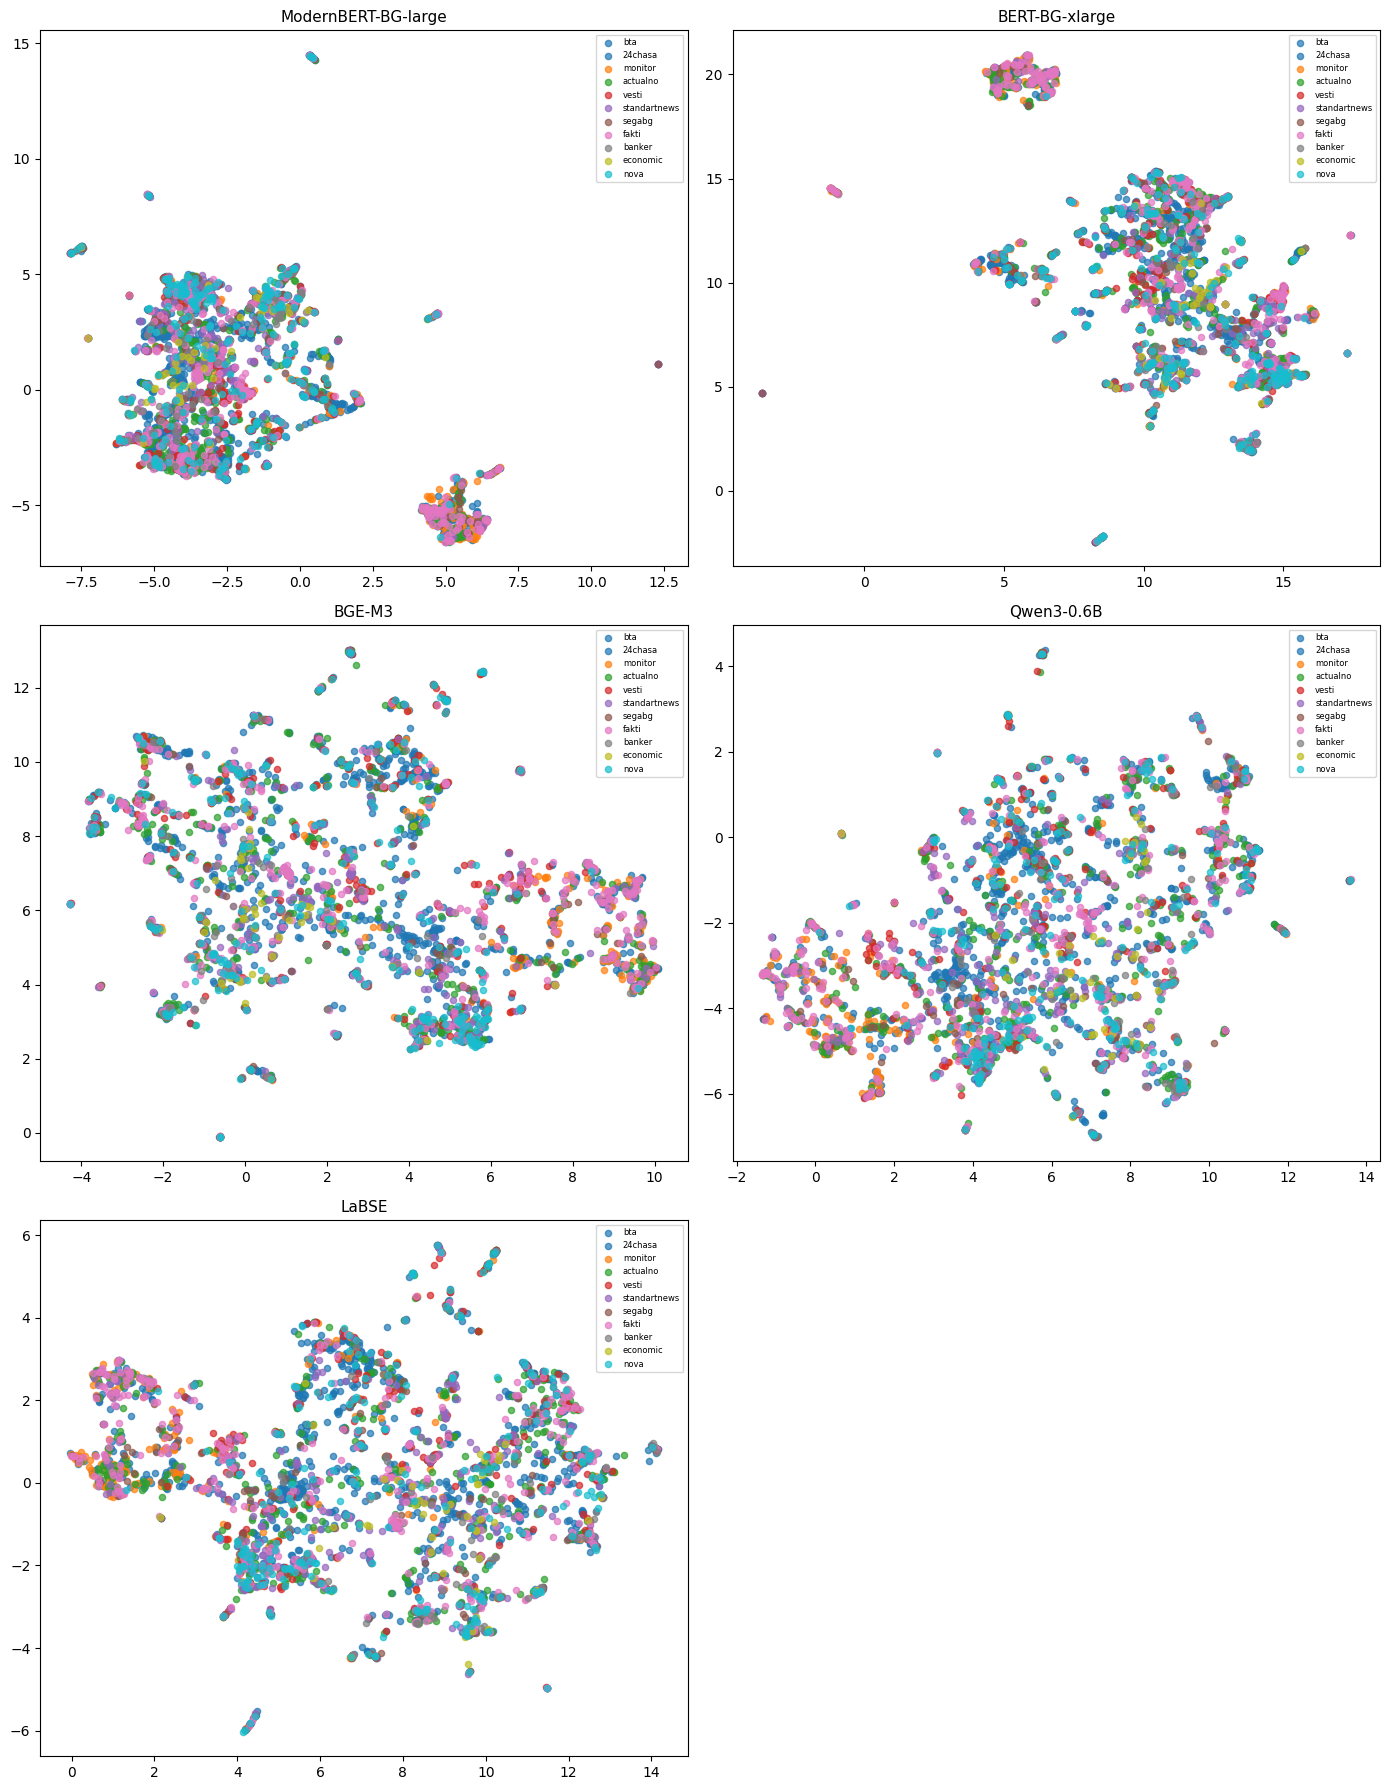

In [21]:
plot_umap_models(model_embeddings, exp_df)

## Model Comparison — UMAP Visualization

**ModernBERT-BG-large** and **BERT-BG-xlarge** show 2–3 large undifferentiated
blobs, confirming the collapsed embedding spaces identified in the metrics.

Among the remaining models, **BGE-M3** shows the most distributed structure
with multiple small distinct groups across the space, consistent with finding
101 clusters. **Qwen3-0.6B** produces a denser, more compressed cloud and
**LaBSE** shows many isolated scattered points, consistent with its 70.4% noise rate.

**BGE-M3 is selected as the embedding model** — it produces the most fine-grained
event separation, the most distinct clusters (101), and the lowest noise ratio
(62.4%) across all viable models.

---

## Final Decision

**Model**: `BAAI/bge-m3`  
**Text input**: `title + lead paragraph`  

# RoBERTa 

In [22]:
from sentence_transformers import SentenceTransformer

roberta_model = SentenceTransformer("rmihaylov/roberta-base-nli-stsb-bg", device=DEVICE)
emb_roberta = roberta_model.encode(
    texts, normalize_embeddings=True, show_progress_bar=True, batch_size=32
)
print(f"Shape: {emb_roberta.shape}")

# save it
np.save("../data/experiments/embeddings/RoBERTa-BG.npy", emb_roberta)

# evaluate
result_roberta = similarity_stats(emb_roberta, "RoBERTa-BG", exp_df)
print(result_roberta)

config.json:   0%|          | 0.00/748 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/515 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Batches:   0%|          | 0/114 [00:00<?, ?it/s]

Shape: (3648, 768)
{'variant': 'RoBERTa-BG', 'same_source_mean': 0.358, 'cross_source_mean': 0.358, 'gap': -0.0, 'cross_source_std': 0.136}


In [24]:
print(result_roberta)

{'variant': 'RoBERTa-BG', 'same_source_mean': 0.358, 'cross_source_mean': 0.358, 'gap': -0.0, 'cross_source_std': 0.136}


In [25]:
result_cluster_roberta = {}
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5, metric="euclidean", cluster_selection_method="eom"
)
labels = clusterer.fit_predict(emb_roberta)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise_ratio = (labels == -1).mean()


if n_clusters >= 2 and n_clusters < len(emb_roberta):
    sil = silhouette_score(emb_roberta, labels, sample_size=5000, random_state=42)
else:
    sil = None

# sources per cluster
sources = exp_df["source"].to_numpy()
cluster_source_counts = []
for cid in set(labels):
    if cid == -1:
        continue
    mask = labels == cid
    n_sources = len(set(sources[mask]))
    cluster_source_counts.append(n_sources)
mean_sources = np.mean(cluster_source_counts) if cluster_source_counts else 0

print(f"n_clusters:             {n_clusters}")
print(f"noise_ratio:            {noise_ratio:.3f}")
print(f"silhouette:             {sil:.4f}" if sil else "silhouette:             N/A")
print(f"mean_sources_per_cluster: {mean_sources:.2f}")

n_clusters:             54
noise_ratio:            0.708
silhouette:             -0.1040
mean_sources_per_cluster: 6.31


<p style="color:#111; font-weight:bold">Similarity Metrics</p>
<table style="background-color:#f0f0f0; border-collapse:collapse; width:100%; color:#111; margin-bottom:20px">
  <thead>
    <tr style="background-color:#bdbdbd; color:#111">
      <th style="padding:8px; border:1px solid #999">Model</th>
      <th style="padding:8px; border:1px solid #999">same_source_mean</th>
      <th style="padding:8px; border:1px solid #999">cross_source_mean</th>
      <th style="padding:8px; border:1px solid #999">gap</th>
      <th style="padding:8px; border:1px solid #999">cross_source_std</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color:#a5d6a7; font-weight:bold">
      <td style="padding:8px; border:1px solid #999">BGE-M3</td>
      <td style="padding:8px; border:1px solid #999">0.311</td>
      <td style="padding:8px; border:1px solid #999">0.308</td>
      <td style="padding:8px; border:1px solid #999">0.003</td>
      <td style="padding:8px; border:1px solid #999">0.069</td>
    </tr>
    <tr>
      <td style="padding:8px; border:1px solid #999">Qwen3-0.6B</td>
      <td style="padding:8px; border:1px solid #999">0.277</td>
      <td style="padding:8px; border:1px solid #999">0.274</td>
      <td style="padding:8px; border:1px solid #999">0.002</td>
      <td style="padding:8px; border:1px solid #999">0.080</td>
    </tr>
    <tr>
      <td style="padding:8px; border:1px solid #999">LaBSE</td>
      <td style="padding:8px; border:1px solid #999">0.259</td>
      <td style="padding:8px; border:1px solid #999">0.254</td>
      <td style="padding:8px; border:1px solid #999">0.005</td>
      <td style="padding:8px; border:1px solid #999">0.094</td>
    </tr>
    <tr>
      <td style="padding:8px; border:1px solid #999">RoBERTa-BG</td>
      <td style="padding:8px; border:1px solid #999">0.358</td>
      <td style="padding:8px; border:1px solid #999">0.358</td>
      <td style="padding:8px; border:1px solid #999">0.000</td>
      <td style="padding:8px; border:1px solid #999">0.136</td>
    </tr>
  </tbody>
</table>

<p style="color:#111; font-weight:bold">HDBSCAN Clustering</p>
<table style="background-color:#f0f0f0; border-collapse:collapse; width:100%; color:#111">
  <thead>
    <tr style="background-color:#bdbdbd; color:#111">
      <th style="padding:8px; border:1px solid #999">Model</th>
      <th style="padding:8px; border:1px solid #999">n_clusters</th>
      <th style="padding:8px; border:1px solid #999">noise_ratio</th>
      <th style="padding:8px; border:1px solid #999">silhouette</th>
      <th style="padding:8px; border:1px solid #999">sources/cluster</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color:#a5d6a7; font-weight:bold">
      <td style="padding:8px; border:1px solid #999">BGE-M3</td>
      <td style="padding:8px; border:1px solid #999">101</td>
      <td style="padding:8px; border:1px solid #999">0.624</td>
      <td style="padding:8px; border:1px solid #999">0.248</td>
      <td style="padding:8px; border:1px solid #999">6.40</td>
    </tr>
    <tr>
      <td style="padding:8px; border:1px solid #999">Qwen3-0.6B</td>
      <td style="padding:8px; border:1px solid #999">86</td>
      <td style="padding:8px; border:1px solid #999">0.635</td>
      <td style="padding:8px; border:1px solid #999">0.235</td>
      <td style="padding:8px; border:1px solid #999">6.60</td>
    </tr>
    <tr>
      <td style="padding:8px; border:1px solid #999">LaBSE</td>
      <td style="padding:8px; border:1px solid #999">86</td>
      <td style="padding:8px; border:1px solid #999">0.704</td>
      <td style="padding:8px; border:1px solid #999">0.260</td>
      <td style="padding:8px; border:1px solid #999">6.21</td>
    </tr>
    <tr>
      <td style="padding:8px; border:1px solid #999">RoBERTa-BG</td>
      <td style="padding:8px; border:1px solid #999">54</td>
      <td style="padding:8px; border:1px solid #999">0.708</td>
      <td style="padding:8px; border:1px solid #999">-0.104</td>
      <td style="padding:8px; border:1px solid #999">6.31</td>
    </tr>
  </tbody>
</table>
<p style="color:#111">Selected model</p>

In [2]:
df = pd.read_parquet("../data/processed/articles_clean.parquet")

end_date = pd.Timestamp("2026-05-21", tz="UTC")
start_date = end_date - pd.Timedelta(days=3)

exp_df = (
    df[(df["published_at_dt"] >= start_date) & (df["published_at_dt"] <= end_date)]
    .copy()
    .reset_index(drop=True)
)

print(f"Total articles : {len(exp_df)}")

Total articles : 3648


/Users/ivanadonchevska/Projects/msc_thesis/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ivanadonchevska/Projects/msc_thesis/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ivanadonchevska/Projects/msc_thesis/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ivanadonchevska/Projects/msc_thesis/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


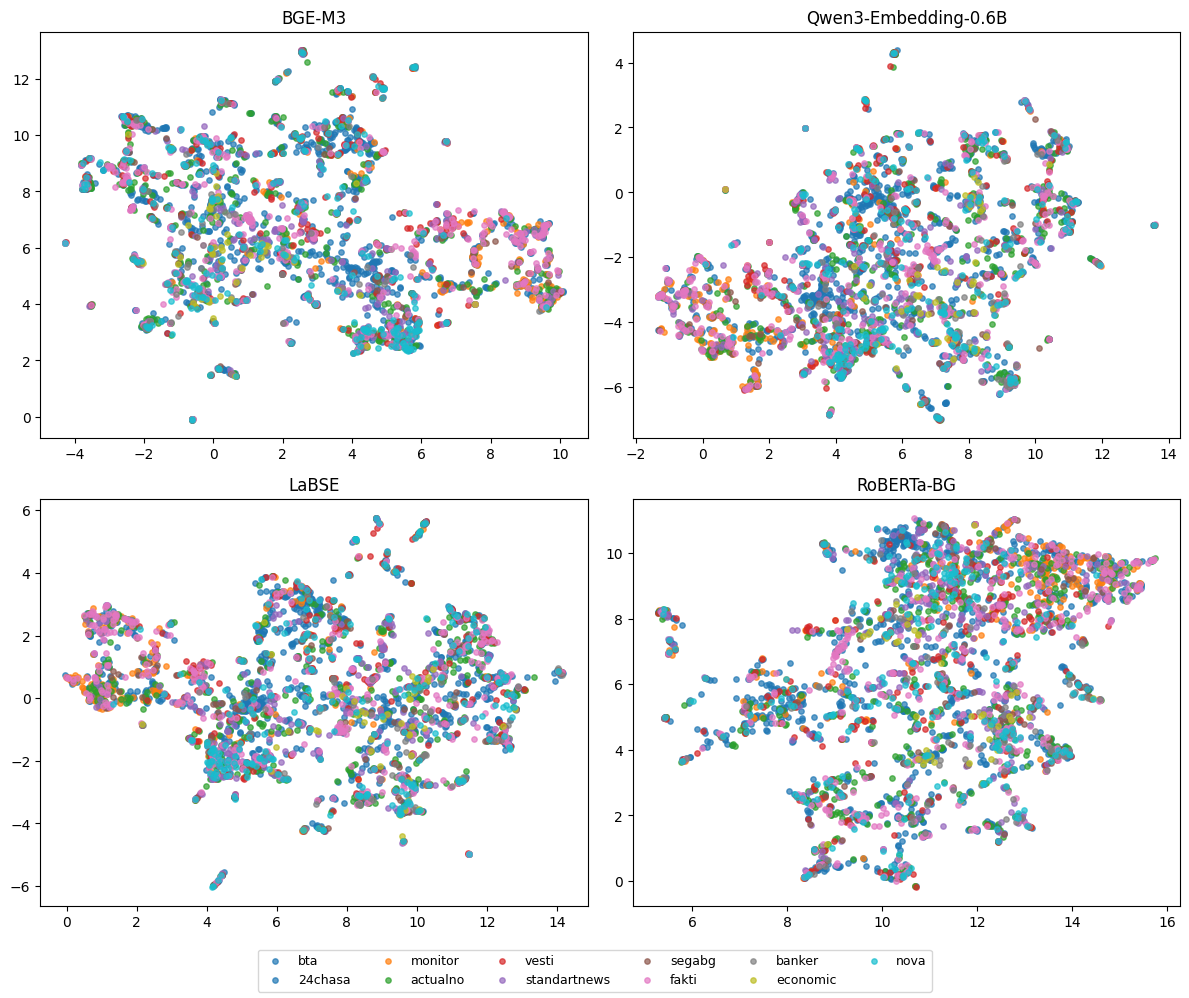

In [3]:
MODEL_FILES = {
    "BGE-M3": "BGE-M3.npy",
    "Qwen3-Embedding-0.6B": "Qwen3-0.6B.npy",
    "LaBSE": "LaBSE.npy",
    "RoBERTa-BG": "RoBERTa-BG.npy",
}

model_embeddings = {
    name: np.load(f"../data/experiments/embeddings/{file}")
    for name, file in MODEL_FILES.items()
}

sources = exp_df["source"].unique()
color_map = {s: cm.tab10(i / len(sources)) for i, s in enumerate(sources)}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, emb) in zip(axes, model_embeddings.items()):
    reducer = umap.UMAP(n_components=2, random_state=42, metric="cosine")
    coords = reducer.fit_transform(emb)
    for source in sources:
        mask = (exp_df["source"] == source).values
        ax.scatter(
            coords[mask, 0],
            coords[mask, 1],
            label=source,
            color=color_map[source],
            alpha=0.7,
            s=15,
        )
    ax.set_title(name, fontsize=12)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncols=6, fontsize=9)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("../figures/umap_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()